# ⏰ Notebook 02 — Time Travel: Returns and the Bellman Equation

**Series**: RL Notebook Series · Act I — Mathematical Foundations · Post 2 of 15

---

## What You'll Learn

In Notebook 01, we built agents and environments and saw that **a good policy matters**. But we never answered the key question:

> **How do we measure how good a policy is?**

The answer is the **value function** — a way to quantify the total future reward from any state. To get there, we need three ideas:

1. **Returns** — the total reward the agent collects from a point in time onward
2. **Discounting** — why a reward now is worth more than a reward later
3. **The Bellman Equation** — a recursive equation that lets us compute value functions efficiently

By the end, you'll understand the equation that underpins **every RL algorithm ever invented**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')

%matplotlib inline
plt.rcParams.update({'figure.figsize': (10, 6), 'axes.grid': True, 'grid.alpha': 0.3})
np.random.seed(42)

from utils.envs import GridEnvironment, ChainMDP

## 1. The Return: Adding Up Future Rewards

Imagine an agent that plays an episode and collects rewards at each step:

$$r_1 = -0.1, \quad r_2 = -0.1, \quad r_3 = -0.1, \quad r_4 = -0.1, \quad r_5 = +1.0$$

The **return** $G_t$ is the total reward from time step $t$ onward:

$$G_t = r_{t+1} + r_{t+2} + r_{t+3} + \dots$$

So for our example:
- $G_0 = -0.1 + (-0.1) + (-0.1) + (-0.1) + 1.0 = 0.6$
- $G_1 = -0.1 + (-0.1) + (-0.1) + 1.0 = 0.7$
- $G_4 = 1.0$

In [2]:
def compute_returns_undiscounted(rewards):
    """Compute the undiscounted return G_t for each time step t."""
    T = len(rewards)
    returns = [0.0] * T
    
    # Work backwards
    returns[T - 1] = rewards[T - 1]
    for t in range(T - 2, -1, -1):
        returns[t] = rewards[t] + returns[t + 1]
    
    return returns

In [3]:
rewards = [-0.1, -0.1, -0.1, -0.1, 1.0]
returns = compute_returns_undiscounted(rewards)

print("Rewards:", rewards)
print("Returns:", [f'{g:.2f}' for g in returns])
print()
print("Expected: G_0=0.60, G_1=0.70, G_2=0.80, G_3=0.90, G_4=1.00")

Rewards: [-0.1, -0.1, -0.1, -0.1, 1.0]
Returns: ['0.60', '0.70', '0.80', '0.90', '1.00']

Expected: G_0=0.60, G_1=0.70, G_2=0.80, G_3=0.90, G_4=1.00


## 2. Discounting: A Reward Now Is Better Than a Reward Later

The undiscounted return has a problem: it treats a reward 1000 steps in the future the same as a reward right now. In most situations, we'd rather get the reward sooner.

The **discounted return** adds a discount factor $\gamma \in [0, 1)$:

$$G_t = r_{t+1} + \gamma \cdot r_{t+2} + \gamma^2 \cdot r_{t+3} + \dots = \sum_{k=0}^{\infty} \gamma^k \cdot r_{t+k+1}$$

**Key insight**: this is recursive!

$$G_t = r_{t+1} + \gamma \cdot G_{t+1}$$

| $\gamma$ | Meaning |
|----------|---------- |
| $\gamma = 0$ | Completely myopic — only cares about the next reward |
| $\gamma = 0.9$ | Values near-term rewards much more |
| $\gamma = 0.99$ | Nearly equal weighting, slight preference for sooner |
| $\gamma = 1$ | Undiscounted (only works for episodic tasks) |

In [4]:
def compute_returns(rewards, gamma=0.99):
    """Compute the discounted return G_t for each time step t."""
    T = len(rewards)
    returns = [0.0] * T
    
    returns[T - 1] = rewards[T - 1]
    for t in range(T - 2, -1, -1):
        returns[t] = rewards[t] + gamma * returns[t + 1]
    
    return returns

In [5]:
rewards = [-0.1, -0.1, -0.1, -0.1, 1.0]

for gamma in [0.0, 0.5, 0.9, 0.99, 1.0]:
    returns = compute_returns(rewards, gamma)
    print(f"gamma={gamma:.2f}: G_0={returns[0]:+.4f}")

gamma=0.00: G_0=-0.1000
gamma=0.50: G_0=-0.1250
gamma=0.90: G_0=+0.3122
gamma=0.99: G_0=+0.5666
gamma=1.00: G_0=+0.6000


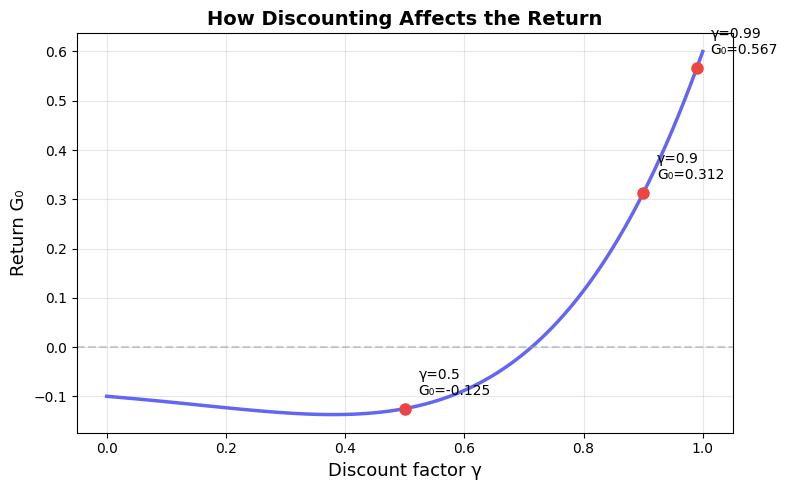

In [6]:
gammas = np.linspace(0, 1, 100)
g0_values = [compute_returns(rewards, g)[0] for g in gammas]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(gammas, g0_values, color='#6366f1', linewidth=2.5)
ax.set_xlabel('Discount factor γ', fontsize=13)
ax.set_ylabel('Return G₀', fontsize=13)
ax.set_title('How Discounting Affects the Return', fontsize=14, fontweight='bold')
ax.axhline(y=0, color='#94a3b8', linestyle='--', alpha=0.5)

for g_mark in [0.5, 0.9, 0.99]:
    g0 = compute_returns(rewards, g_mark)[0]
    ax.plot(g_mark, g0, 'o', markersize=8, color='#ef4444')
    ax.annotate(f'γ={g_mark}\nG₀={g0:.3f}', (g_mark, g0),
               textcoords='offset points', xytext=(10, 10), fontsize=10)

plt.tight_layout()
plt.show()

### 💡 Insight: Why Discounting?

1. **Mathematical convenience**: guarantees $G_t$ is finite even for infinite horizons
2. **Models uncertainty**: the further in the future, the less sure we are we'll get there
3. **Models preference**: humans and animals prefer immediate rewards (hyperbolic discounting)
4. **Economic intuition**: money today is worth more than money tomorrow (time value of money)

---

## 3. The Value Function: How Good Is a State?

The **state-value function** $V^\pi(s)$ answers: "If I'm in state $s$ and I follow policy $\pi$, what is my **expected** return?"

$$V^\pi(s) = \mathbb{E}_\pi[G_t \mid S_t = s]$$

### What does "expected" mean here?

If you've seen **expected value** in probability, this is exactly the same idea. The expected value of a random variable is its average over many trials:

$$\mathbb{E}[X] = \sum_x x \cdot P(x)$$

The return $G_t$ is random — it depends on which actions the policy picks and where the environment sends us. So $V^\pi(s)$ is just the **average return** we'd get if we started in state $s$ and played many, many episodes following policy $\pi$.

> 📚 Need a refresher on expected value? [This 3Blue1Brown video](https://www.youtube.com/watch?v=8idr1WZ1A7Q) gives a beautiful visual explanation, or see [Khan Academy's intro](https://www.khanacademy.org/math/statistics-probability/random-variables-stats-library/random-variables-discrete/v/expected-value-of-a-discrete-random-variable).

### Estimating $V^\pi$ by Sampling (The Monte Carlo Idea)

How do we compute this average in practice? We use **Monte Carlo sampling** — which is just a fancy name for a simple idea:

> **Run the experiment many times and average the results.**

Named after the Monte Carlo casino (because it involves randomness!), this technique shows up everywhere in science and engineering. Here, it means:

1. Play 10,000 episodes following policy $\pi$
2. Each time the agent visits state $s$, note down the return $G_t$ it got from that point
3. Average all those returns → that's your estimate of $V^\pi(s)$

$$\hat{V}^\pi(s) \approx \frac{1}{N} \sum_{i=1}^{N} G_t^{(i)} \quad \text{where } S_t^{(i)} = s$$

The more episodes we run, the closer our estimate gets to the true value. Simple!

### Your Task: Estimate the Value Function by Sampling

In [7]:
def estimate_V_monte_carlo(env, policy_fn, n_episodes=5000, gamma=0.9, max_steps=100):
    """
    Estimate V^pi(s) for all states by running episodes and averaging returns.
    """
    total_returns = np.zeros(env.n_states)
    visit_counts = np.zeros(env.n_states)
    
    for _ in range(n_episodes):
        state = env.reset()
        trajectory = []  # list of (state, reward)
        
        for _ in range(max_steps):
            action = policy_fn(state)
            next_state, reward, done, _ = env.step(action)
            trajectory.append((state, reward))
            state = next_state
            if done:
                break
        
        # Compute returns for this trajectory
        T = len(trajectory)
        G = 0
        for t in range(T - 1, -1, -1):
            s, r = trajectory[t]
            G = r + gamma * G
            total_returns[s] += G
            visit_counts[s] += 1
    
    # Average
    V = np.zeros(env.n_states)
    for s in range(env.n_states):
        if visit_counts[s] > 0:
            V[s] = total_returns[s] / visit_counts[s]
    
    return V

In [8]:
env = GridEnvironment(rows=4, cols=4, start=(0,0), goal=(3,3),
                      walls=[(1,1)], traps=[(1,3), (3,0)])

def random_policy(state):
    return np.random.randint(4)

V_random = estimate_V_monte_carlo(env, random_policy, n_episodes=10000, gamma=0.9)

print("Estimated V^π (random policy), γ=0.9:")
print(V_random.reshape(4, 4).round(3))

Estimated V^π (random policy), γ=0.9:
[[-0.96  -0.956 -0.931 -0.969]
 [-0.946  0.    -0.831  0.   ]
 [-0.908 -0.747 -0.532 -0.213]
 [ 0.    -0.679 -0.146  0.   ]]


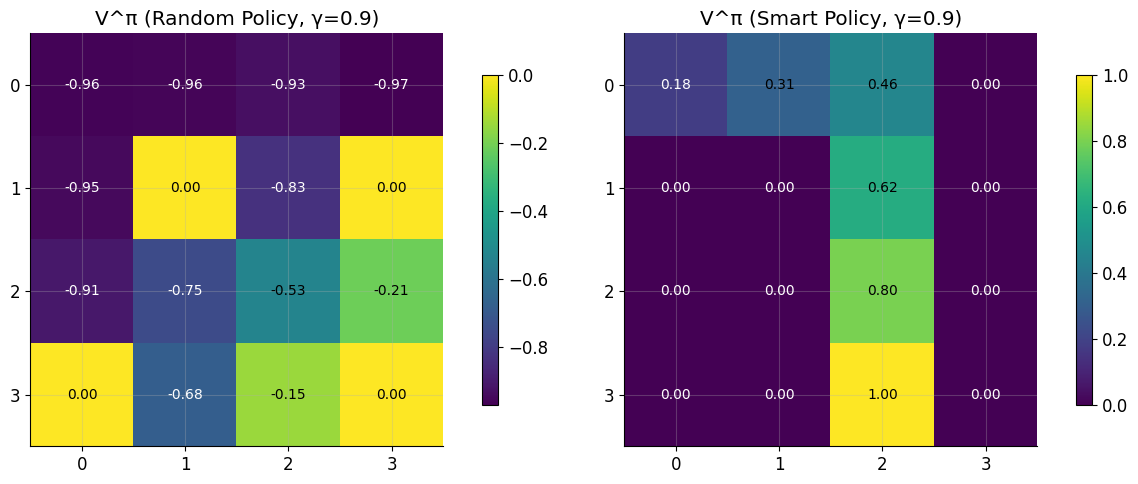


Random policy — V(start): -0.960
Smart policy  — V(start): 0.181
→ The smart policy's value is much higher everywhere!


In [9]:
from utils.plotting import plot_values_grid

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_values_grid(V_random, (4, 4), title="V^π (Random Policy, γ=0.9)", ax=axes[0])

smart_policy_dict = {
    0: 1, 1: 1, 2: 2, 3: 2,
    4: 2, 6: 2,
    8: 1, 9: 1, 10: 2, 11: 2,
    13: 1, 14: 1,
}
def smart_policy(state):
    return smart_policy_dict.get(state, 1)

V_smart = estimate_V_monte_carlo(env, smart_policy, n_episodes=10000, gamma=0.9)
plot_values_grid(V_smart, (4, 4), title="V^π (Smart Policy, γ=0.9)", ax=axes[1])

plt.tight_layout()
plt.show()

print(f"\nRandom policy — V(start): {V_random[0]:.3f}")
print(f"Smart policy  — V(start): {V_smart[0]:.3f}")
print("→ The smart policy's value is much higher everywhere!")

## 4. The Action-Value Function: How Good Is an Action?

Sometimes we want to know how good it is to take a **specific action** $a$ in state $s$:

$$Q^\pi(s, a) = \mathbb{E}_\pi[G_t \mid S_t = s, A_t = a]$$

The relationship between $V$ and $Q$:

$$V^\pi(s) = \sum_a \pi(a|s) \cdot Q^\pi(s, a)$$

🤔 **Why Q?** Later (Notebook 04), we'll see that Q-values let us **improve** the policy — just pick the action with the highest Q-value! This is why Q-learning is so powerful.

## 5. The Bellman Equation: The Big Idea

Here's the key insight. Remember the recursive formula for returns?

$$G_t = r_{t+1} + \gamma \cdot G_{t+1}$$

If we take the **expectation** of both sides:

$$V^\pi(s) = \mathbb{E}_\pi[r_{t+1} + \gamma \cdot V^\pi(S_{t+1}) \mid S_t = s]$$

Expanding:

$$V^\pi(s) = \sum_a \pi(a|s) \sum_{s'} P(s'|s,a) \big[ R(s,a,s') + \gamma \cdot V^\pi(s') \big]$$

This is the **Bellman Expectation Equation**!

```
Value of state s = weighted average over all actions a I might take
                    of: weighted average over all next states s'
                        of: [immediate reward + discounted value of s']
```

It expresses $V^\pi(s)$ in terms of $V^\pi(s')$ for neighbouring states. This recursive structure means we can solve for V **without running episodes**.

## 6. Hands-On: Solving the Bellman Equation for a Chain MDP

Consider a 5-state chain:

```
[0] ← [1] ← [2] → [3] → [4]
 T              S         T
```

- States 0 and 4 are terminal
- State 2 is the start
- Reaching state 0: reward 0.0, state 4: reward 1.0
- Each intermediate step: reward -0.01

### Policy: always go RIGHT

In [10]:
chain = ChainMDP(n=5, left_reward=0.0, right_reward=1.0, step_reward=-0.01)
gamma = 0.9

def always_right(state):
    return 1

# Hand-computed values:
# V(0) = 0.0 (terminal)
# V(4) = 0.0 (terminal)
# V(3) = 1.0 + 0.9 * 0 = 1.0
# V(2) = -0.01 + 0.9 * 1.0 = 0.89
# V(1) = -0.01 + 0.9 * 0.89 = 0.791

V_hand = np.array([0.0, 0.791, 0.89, 1.0, 0.0])

print("Hand-computed values:  ", V_hand)

V_mc = estimate_V_monte_carlo(chain, always_right, n_episodes=10000, gamma=gamma)
print("Monte Carlo estimates: ", V_mc.round(4))
print("\nDo they match? (within sampling error)")

Hand-computed values:   [0.    0.791 0.89  1.    0.   ]
Monte Carlo estimates:  [0.   0.   0.89 1.   0.  ]

Do they match? (within sampling error)


### 🔍 Derivation: From the Bellman Equation to Linear Algebra

**Step 1: The Bellman Equation (per state)**

For a fixed policy, the Bellman equation for state `s` is:

```
V(s) = r(s) + γ · Σ P(s→s') · V(s')
```

The value of `s` = immediate reward + discounted weighted sum of the values of all next states `s'`.

---

**Step 2: One equation per state → a system of equations**

With `n` states, we get `n` simultaneous equations. For 3 states (0, 1, 2):

```
V(0) = r(0) + γ · [P(0→0)·V(0) + P(0→1)·V(1) + P(0→2)·V(2)]
V(1) = r(1) + γ · [P(1→0)·V(0) + P(1→1)·V(1) + P(1→2)·V(2)]
V(2) = r(2) + γ · [P(2→0)·V(0) + P(2→1)·V(1) + P(2→2)·V(2)]
```

The unknowns are `V(0)`, `V(1)`, `V(2)`. This is a **system of linear equations**!

---

**Step 3: Write it in matrix form**

```
V  =  r  +  γ · P · V
```

where:
- **V** = column vector of all state values `[V(0), V(1), ..., V(n-1)]`
- **r** = column vector of immediate rewards
- **P** = n×n transition matrix, where entry `[s][s']` = probability of going from `s` to `s'`

---

**Step 4: Solve for V algebraically**

```
V - γ · P · V = r
(I - γ · P) · V = r
V = inverse(I - γ · P) · r
```

This is exactly what `np.linalg.solve(A, r_pi)` does below — it solves `A·V = r` where `A = I - γ·P`.

> **Why is this linear?** The unknowns `V(s')` appear only multiplied by *known* constants (the transition probabilities). No products of V with itself, no max — just a weighted sum. That's what makes it linear and solvable with standard matrix inversion.
>
> The **Bellman Optimality Equation** (for finding the *best* policy) involves a `max` over actions, which breaks linearity and requires iterative methods instead.

## 7. The Bellman Equation as a System of Linear Equations

For a fixed policy with known dynamics:

$$\mathbf{V} = \mathbf{r}^\pi + \gamma \mathbf{P}^\pi \mathbf{V}$$

$$\mathbf{V} = (\mathbf{I} - \gamma \mathbf{P}^\pi)^{-1} \mathbf{r}^\pi$$

Exact, but $O(n^3)$ — only practical for small MDPs.

In [11]:
def solve_bellman_exact(env, policy_fn, gamma=0.9):
    """
    Solve V^pi exactly using the matrix equation V = (I - gamma*P^pi)^{-1} * r^pi.
    """
    n = env.n_states
    
    # Build P^pi and r^pi
    P_pi = np.zeros((n, n))
    r_pi = np.zeros(n)
    
    for s in range(n):
        a = policy_fn(s)
        for prob, next_state, reward, done in env.P[s][a]:
            P_pi[s, next_state] += prob
            r_pi[s] += prob * reward
    
    # Solve (I - gamma * P^pi) V = r^pi
    A = np.eye(n) - gamma * P_pi
    V = np.linalg.solve(A, r_pi)
    
    return V

In [12]:
V_exact = solve_bellman_exact(chain, always_right, gamma=0.9)

print("Exact solution:        ", V_exact.round(4))
print("Hand-computed:         ", V_hand.round(4))
print("Monte Carlo estimate:  ", V_mc.round(4))
print("\n→ The exact solution matches your hand computation perfectly!")

Exact solution:         [0.    0.791 0.89  1.    0.   ]
Hand-computed:          [0.    0.791 0.89  1.    0.   ]
Monte Carlo estimate:   [0.   0.   0.89 1.   0.  ]

→ The exact solution matches your hand computation perfectly!


### 💡 Insight: Why does Monte Carlo estimate $V(1) = 0.0$?

You might notice a discrepancy: the exact value is $0.791$, but Monte Carlo says $0.0$. Is it a bug?

No! It highlights a fundamental limitation of Monte Carlo. Our `ChainMDP` always starts in state 2, and our policy always goes RIGHT. The agent **never visits state 1**, so it never collects any returns from it.

**Monte Carlo can only learn about states it visits.** This is the core reasoning behind the **Exploration vs. Exploitation** tradeoff — an agent must explore to find true values.

### 💡 Insight: Why does Monte Carlo estimate $V(1) = 0.0$?

You might notice a discrepancy: the exact value is $0.791$, but Monte Carlo says $0.0$. Is it a bug?

No! It highlights a fundamental limitation of Monte Carlo. Our `ChainMDP` always starts in state 2, and our policy always goes RIGHT. The agent **never visits state 1**, so it never collects any returns from it.

**Monte Carlo can only learn about states it visits.** This is the core reasoning behind the **Exploration vs. Exploitation** tradeoff — an agent must explore to find true values.

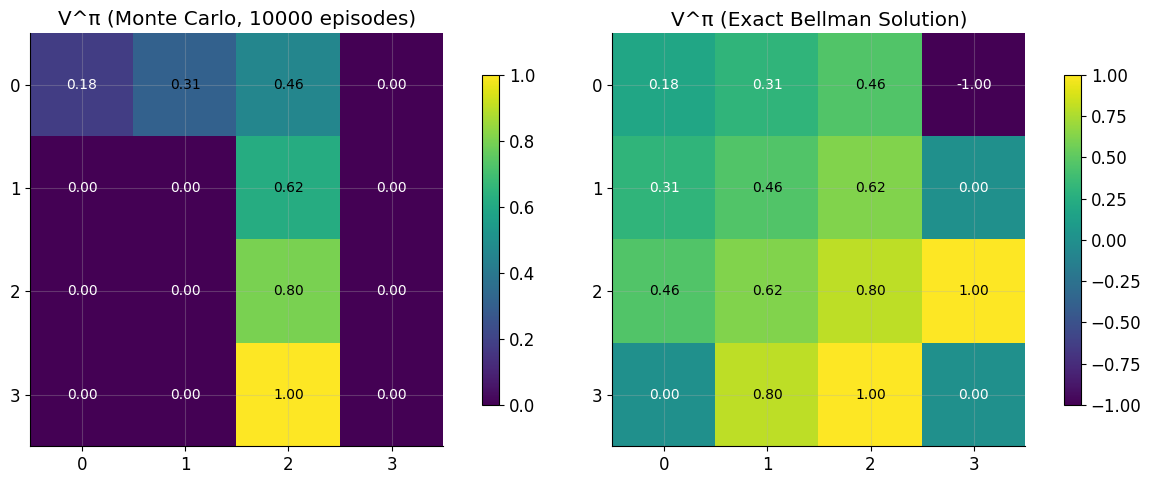

Max difference: 1.0000
→ Monte Carlo converges toward the exact solution!


In [13]:
V_grid_exact = solve_bellman_exact(env, smart_policy, gamma=0.9)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_values_grid(V_smart, (4, 4), title="V^π (Monte Carlo, 10000 episodes)", ax=axes[0])
plot_values_grid(V_grid_exact, (4, 4), title="V^π (Exact Bellman Solution)", ax=axes[1])
plt.tight_layout()
plt.show()

print(f"Max difference: {np.max(np.abs(V_smart - V_grid_exact)):.4f}")
print("→ Monte Carlo converges toward the exact solution!")

## 8. The Bellman Optimality Equation

The **best possible** value:

$$V^*(s) = \max_a \sum_{s'} P(s'|s,a) \big[ R(s,a,s') + \gamma \cdot V^*(s') \big]$$

| Bellman Expectation | Bellman Optimality |
|---------------------|--------------------|
| Takes a **weighted average** over actions (according to π) | Takes the **max** over actions |
| Evaluates a specific policy | Finds the optimal policy |
| Can be solved with linear algebra | Non-linear — needs iteration |

The max makes it non-linear → we need **iterative methods** — subject of **Notebook 03: Dynamic Programming**.

## 9. Discount Factor Sensitivity: An Experiment

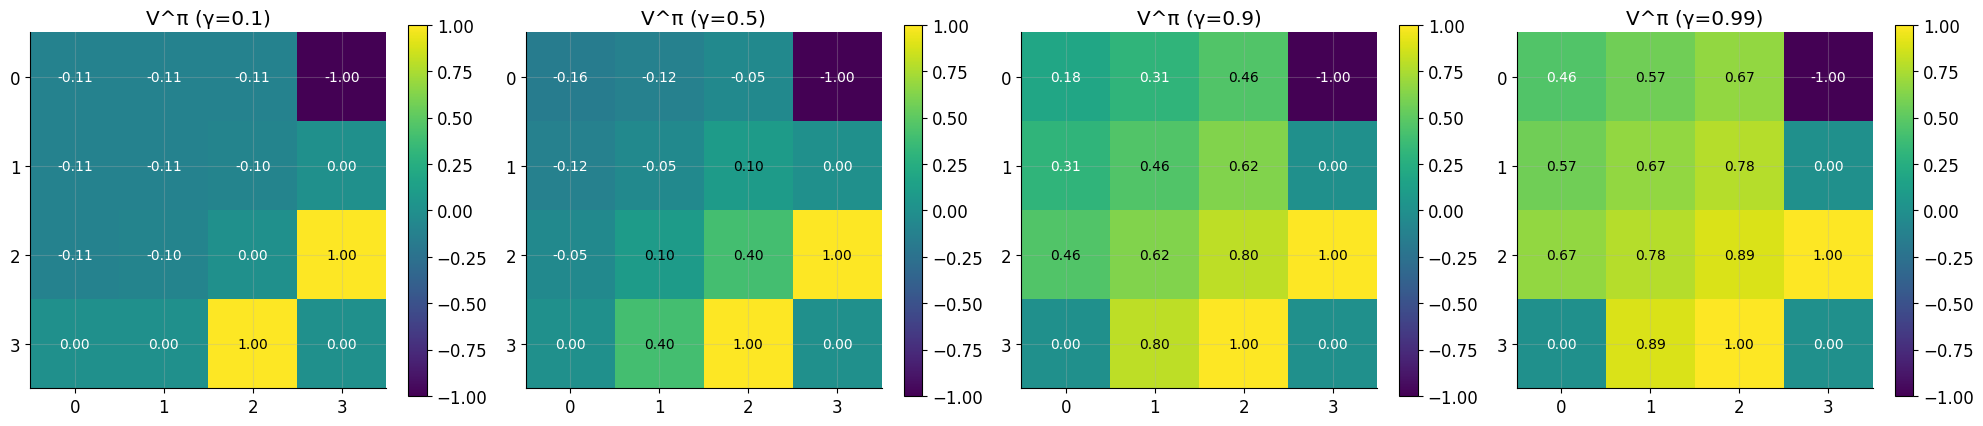

With low γ, only states near the goal have high value.
With high γ, even distant states have significant value.


In [14]:
gammas_to_try = [0.1, 0.5, 0.9, 0.99]

fig, axes = plt.subplots(1, len(gammas_to_try), figsize=(5 * len(gammas_to_try), 5))

for i, g in enumerate(gammas_to_try):
    V = solve_bellman_exact(env, smart_policy, gamma=g)
    plot_values_grid(V, (4, 4), title=f"V^π (γ={g})", ax=axes[i])

plt.tight_layout()
plt.show()

print("With low γ, only states near the goal have high value.")
print("With high γ, even distant states have significant value.")

## 10. Recap & Key Takeaways

### What we built:
- ✅ **Return computation** — both undiscounted and discounted ($G_t = r_{t+1} + \gamma G_{t+1}$)
- ✅ **Monte Carlo value estimation** — estimate $V^\pi$ by averaging sampled returns
- ✅ **Hand-solved the Bellman equation** for a 5-state chain MDP
- ✅ **Exact Bellman solution** via matrix algebra $(\mathbf{I} - \gamma \mathbf{P}^\pi)^{-1} \mathbf{r}^\pi$
- ✅ **Discount factor sensitivity** experiment

### Key equations:

| Equation | Formula |
|----------|---------- |
| **Discounted Return** | $G_t = r_{t+1} + \gamma G_{t+1}$ |
| **State-Value Function** | $V^\pi(s) = \mathbb{E}_\pi[G_t \mid S_t = s]$ |
| **Action-Value Function** | $Q^\pi(s, a) = \mathbb{E}_\pi[G_t \mid S_t = s, A_t = a]$ |
| **Bellman Expectation** | $V^\pi(s) = \sum_a \pi(a|s) \sum_{s'} P(s'|s,a)[R + \gamma V^\pi(s')]$ |
| **Bellman Optimality** | $V^*(s) = \max_a \sum_{s'} P(s'|s,a)[R + \gamma V^*(s')]$ |

### The big question:

> We can now *evaluate* any policy. But how do we *find* the optimal one?

That's **Dynamic Programming** — **Notebook 03: The Spreadsheet of the Mind**.

---

## 🧪 Exercises (Optional Challenges)

1. **Random policy on the chain**: What is $V^\pi$ if the policy is 50/50 left/right? Solve by hand and verify with Monte Carlo.

2. **Monte Carlo convergence**: Plot how the MC estimate of $V(s_0)$ improves as you increase the number of episodes.

3. **Q-values**: Extend `estimate_V_monte_carlo` to also estimate $Q^\pi(s,a)$.

4. **Bigger MDP**: Try a 10-state chain. Does the matrix inversion still work?

---

*Next up: [Notebook 03 — The Spreadsheet of the Mind: Dynamic Programming & Value Iteration](03_dynamic_programming.ipynb)*